# 04 — Experiment 3: ambulatory motion

`E3_walk` — 180 s recording: 0-60 s seated, 60-120 s walking, 120-180 s recovery.

Anchor seated reference: **E1B** (sitting 5 min). Walking HRV is flagged
**unreliable** due to motion artifact; we still report it for completeness.

**Deliverables**:
- full tachogram with segment shading.
- raw ECG 15 s per segment (shows motion artifact in walking).
- recovery HR with exponential tau fit.
- ECG PSD per regime with a walking accelerometer PSD reference panel.
- motion-g(t) with smoothed envelope aligned to the RR tachogram.
- Table 3.1 — per-segment stats + anchor comparison.


In [23]:
from __future__ import annotations

import sys
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src import config as cfg
from src import pipeline as P
from src import plotting as PL

PL.apply_style()
warnings.filterwarnings('ignore', category=RuntimeWarning)

FIG_DIR = REPO_ROOT / 'outputs' / 'figures'
TBL_DIR = REPO_ROOT / 'outputs' / 'tables'
FIG_DIR.mkdir(parents=True, exist_ok=True)
TBL_DIR.mkdir(parents=True, exist_ok=True)
print('Setup complete. Sessions available:', len(cfg.SESSION_MAP))

Setup complete. Sessions available: 14


## 1. Load pipeline + anchor + gsen

In [24]:
r  = P.analyze_transient_event("E3_walk")
r_anc = P.analyze_steady_state("E1B")
t_g, motion_g = P.load_gsen("E3_walk")
print(f"E3_walk:  {r.peaks_nk.size} peaks over {r.ecg_raw.size/cfg.FS:.1f}s")
print(f"E1B anchor: HR={r_anc.td_hrv['mean_hr_bpm']:.1f} bpm, HF={r_anc.fd_hrv['hf_ms2']:.0f} ms²")
for seg, d in r.extras["transient_hrv"].items():
    print(f"  {seg:10s}: HR={d['mean_hr_bpm']:.1f} bpm  RMSSD={d['rmssd_ms']:.1f}  "
          f"slope={d['hr_slope_bpm_per_s']:+.3f}  n_beats={d['n_beats']}")

E3_walk:  213 peaks over 180.0s
E1B anchor: HR=56.1 bpm, HF=1123 ms²
  seated    : HR=60.8 bpm  RMSSD=54.4  slope=-0.055  n_beats=60
  walking   : HR=83.0 bpm  RMSSD=41.1  slope=-0.120  n_beats=82
  recovery  : HR=70.3 bpm  RMSSD=46.9  slope=-0.134  n_beats=70


## 2. full tachogram with segment shading

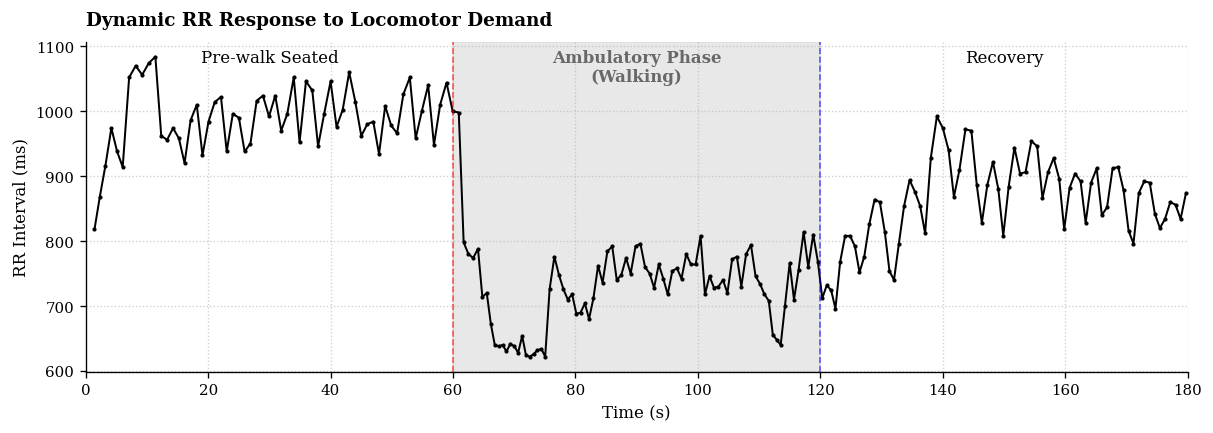

In [25]:
import matplotlib.pyplot as plt

# 1. 統一 IEEE 標準字體設定
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
})

fig, ax = plt.subplots(figsize=(10, 3.5), constrained_layout=True)

# 2. 繪製精緻的 Tachogram
PL.plot_rr_tachogram(r.rr_ms_nk, r.rr_times_nk, ax=ax, 
                     color='black', lw=1.2) # 在 E3 使用黑色線條會顯得更專業沉穩

# 3. 優化陰影與標記 (只 Highlight 步行區段)
t0, t1 = cfg.E3_SEG["walking"]
ax.axvspan(t0, t1, color='#D3D3D3', alpha=0.5, zorder=-1)
ax.axvline(t0, color='red', linestyle='--', alpha=0.6, lw=1)
ax.axvline(t1, color='blue', linestyle='--', alpha=0.6, lw=1)

# 加入專業標註
ax.text((t0+t1)/2, ax.get_ylim()[1] * 0.99, "Ambulatory Phase\n(Walking)", 
        ha="center", va="top", fontsize=10, fontweight='bold', color='dimgray')
ax.text(t0/2, ax.get_ylim()[1] * 0.99, "Pre-walk Seated", ha="center", va="top", fontsize=10)
ax.text(t1 + (180-t1)/2, ax.get_ylim()[1] * 0.99, "Recovery", ha="center", va="top", fontsize=10)

# 4. 座標與標題設定
ax.set_xlim(0, 180)
ax.set_xlabel("Time (s)")
ax.set_ylabel("RR Interval (ms)")
ax.set_title("Dynamic RR Response to Locomotor Demand", loc='left', fontweight='bold', pad=10)
ax.grid(True, linestyle=':', alpha=0.6)

PL.save_figure(fig, 'nb04_fig01_e3_tachogram.pdf')
plt.show()

## 3. raw ECG 15 s per segment (motion artifact visible)

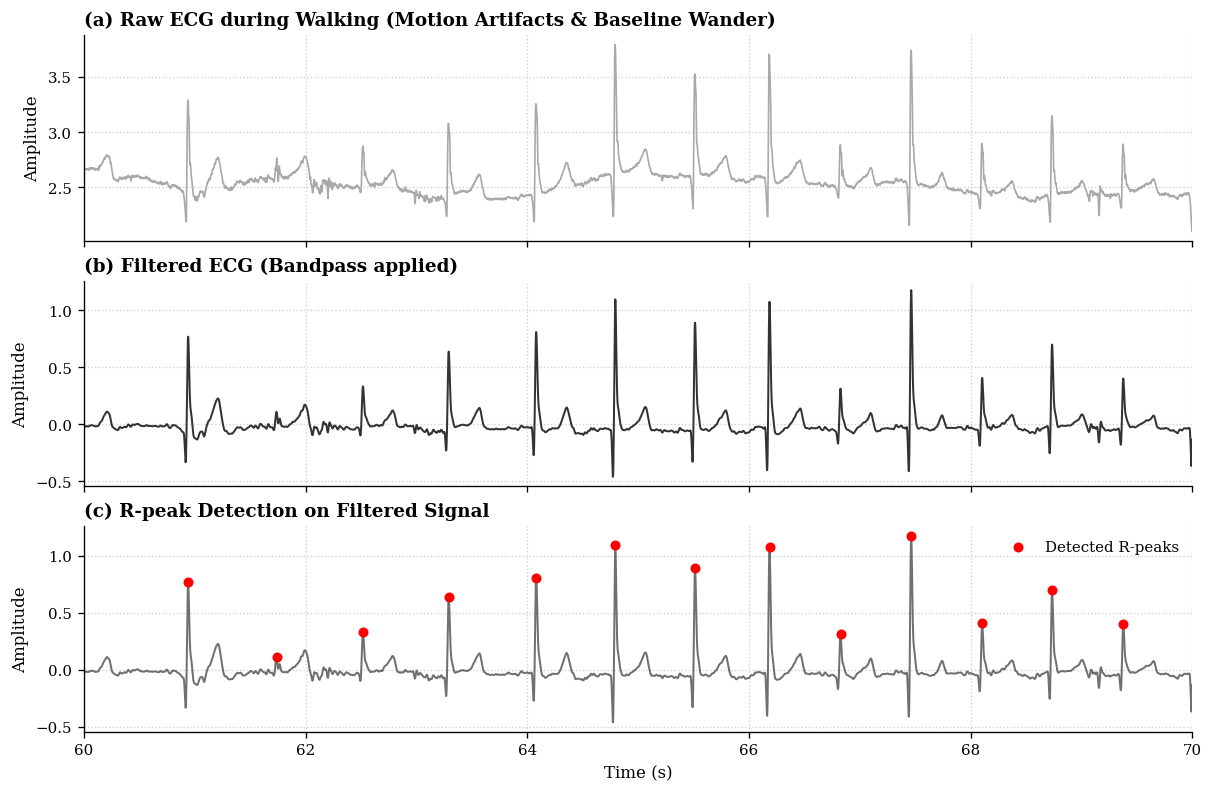

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 統一 IEEE 標準字體設定
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
})

# 2. 挑選「步行階段」中最嚴峻的 10 秒鐘
t0w, t1w = cfg.E3_SEG["walking"]
view_start = t0w   # 假設步行開始
view_end = view_start + 10

# 找出對應的 index
i0 = int(view_start * cfg.FS)
i1 = int(view_end * cfg.FS)

t_view = r.t[i0:i1]
raw_view = r.ecg_raw[i0:i1]
filt_view = r.ecg_filt[i0:i1]

# 找出在這個視窗內的 R-peaks
valid_peaks = r.peaks_nk[(r.peaks_nk >= i0) & (r.peaks_nk < i1)]
peak_t = r.t[valid_peaks]
peak_y = r.ecg_filt[valid_peaks]

# 3. 建立 3x1 畫布
fig, axes = plt.subplots(3, 1, figsize=(10, 6.5), sharex=True, constrained_layout=True)

# (a) Raw ECG
axes[0].plot(t_view, raw_view, color="#A9A9A9", lw=1.0)
axes[0].set_title("(a) Raw ECG during Walking (Motion Artifacts & Baseline Wander)", loc='left', fontweight='bold')
axes[0].set_ylabel("Amplitude")

# (b) Filtered ECG
axes[1].plot(t_view, filt_view, color="#333333", lw=1.2)
axes[1].set_title("(b) Filtered ECG (Bandpass applied)", loc='left', fontweight='bold')
axes[1].set_ylabel("Amplitude")

# (c) Peak Detection
axes[2].plot(t_view, filt_view, color="#333333", lw=1.2, alpha=0.7)
axes[2].scatter(peak_t, peak_y, color="red", s=25, zorder=3, label="Detected R-peaks")
axes[2].set_title("(c) R-peak Detection on Filtered Signal", loc='left', fontweight='bold')
axes[2].set_ylabel("Amplitude")
axes[2].set_xlabel("Time (s)")
axes[2].legend(loc='upper right', fontsize=9)

# 統一網格
for ax in axes:
    ax.grid(True, linestyle=':', alpha=0.6)

# 限制 X 軸顯示範圍
axes[-1].set_xlim(view_start, view_end)

PL.save_figure(fig, 'nb04_fig02_e3_ecg_snapshots.pdf')
plt.show()

## 4. recovery HR with exponential tau fit

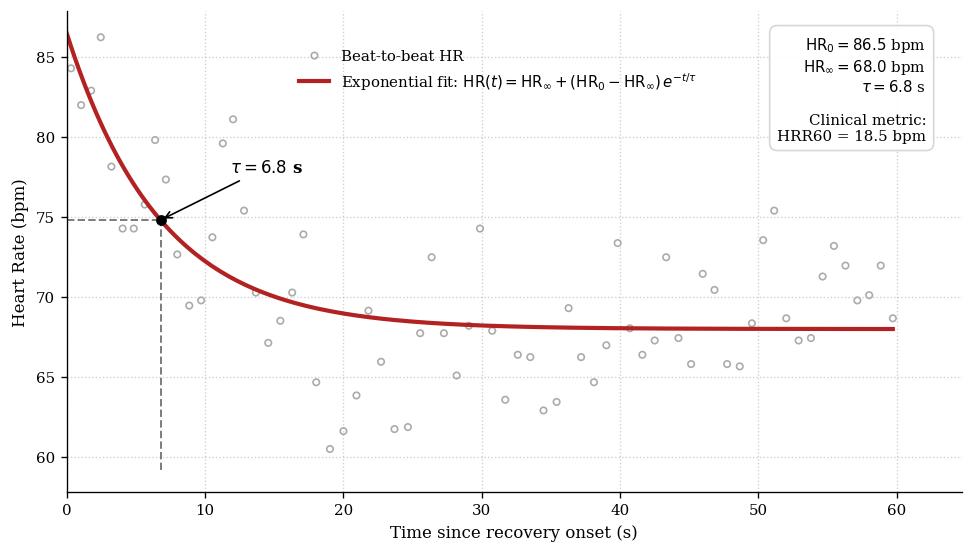

In [27]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# 1. 統一 IEEE 標準字體設定
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'legend.fontsize': 9
})

def exp_decay(t, A, tau, C):
    return A * np.exp(-t / tau) + C

t_rec0, t_rec1 = cfg.E3_SEG["recovery"]
mask = (r.rr_times_nk >= t_rec0) & (r.rr_times_nk < t_rec1)
t_rec = r.rr_times_nk[mask] - t_rec0
hr_rec = 60000.0 / r.rr_ms_nk[mask]

try:
    popt, _ = curve_fit(exp_decay, t_rec, hr_rec,
                        p0=[hr_rec[0]-hr_rec[-1], 20.0, hr_rec[-1]],
                        maxfev=5000)
    A, tau, C = popt
    t_fit = np.linspace(0, t_rec.max(), 200)
    hr_fit = exp_decay(t_fit, *popt)
    fit_ok = True
except Exception as exc:
    A = tau = C = float("nan"); fit_ok = False
    print(f"Fit failed: {exc}")

# 2. 開始繪製頂刊等級圖表
fig, ax = plt.subplots(figsize=(8, 4.5), constrained_layout=True)

# 繪製原始數據 (使用灰色半透明，弱化高頻雜訊的干擾)
ax.scatter(t_rec, hr_rec, facecolor='none', edgecolor='#888888', s=15, alpha=0.7, label="Beat-to-beat HR")

if fit_ok:
    # 繪製擬合曲線 (使用搶眼的深紅色)
    ax.plot(t_fit, hr_fit, "-", color="#B22222", linewidth=2.5, 
            label=r"Exponential fit: $\mathrm{HR}(t) = \mathrm{HR}_{\infty} + (\mathrm{HR}_{0} - \mathrm{HR}_{\infty})\,e^{-t/\tau}$")
    
    # 【關鍵視覺化】：標示 Tau 的位置 (下降 63.2%)
    hr_at_tau = exp_decay(tau, *popt)
    ax.plot([tau, tau], [ax.get_ylim()[0], hr_at_tau], 'k--', alpha=0.5, lw=1.2)
    ax.plot([0, tau], [hr_at_tau, hr_at_tau], 'k--', alpha=0.5, lw=1.2)
    ax.scatter([tau], [hr_at_tau], color='black', s=30, zorder=5)
    
    # 標註 Tau
    ax.annotate(rf'$\tau = {tau:.1f}$ s', xy=(tau, hr_at_tau), xytext=(tau + 5, hr_at_tau + 3),
                arrowprops=dict(arrowstyle="->", color='black', connectionstyle="arc3"),
                fontsize=10, fontweight='bold')

    # 計算臨床常用指標 HRR60 (Recovery after 1 minute)
    hr_0 = exp_decay(0, *popt)
    hr_60 = exp_decay(60, *popt)
    hrr_60 = hr_0 - hr_60

    # 製作精緻的數據面板
    stats_text = (
        f"$\\mathrm{{HR}}_0 = {A + C:.1f}$ bpm\n"
        f"$\\mathrm{{HR}}_\\infty = {C:.1f}$ bpm\n"
        f"$\\tau = {tau:.1f}$ s\n\n"
        f"Clinical metric:\n"
        f"HRR60 = {hrr_60:.1f} bpm"
    )
    ax.text(0.96, 0.95, stats_text, transform=ax.transAxes,
            fontsize=9, verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='lightgray'))

ax.set_xlabel("Time since recovery onset (s)")
ax.set_ylabel("Heart Rate (bpm)")
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='upper right', bbox_to_anchor=(0.72, 0.95))
ax.set_xlim(0, t_rec.max() + 5)

PL.save_figure(fig, 'nb04_fig03_e3_recovery_tau.pdf')
plt.show()

## 5. ECG PSD per regime + walking accelerometer PSD


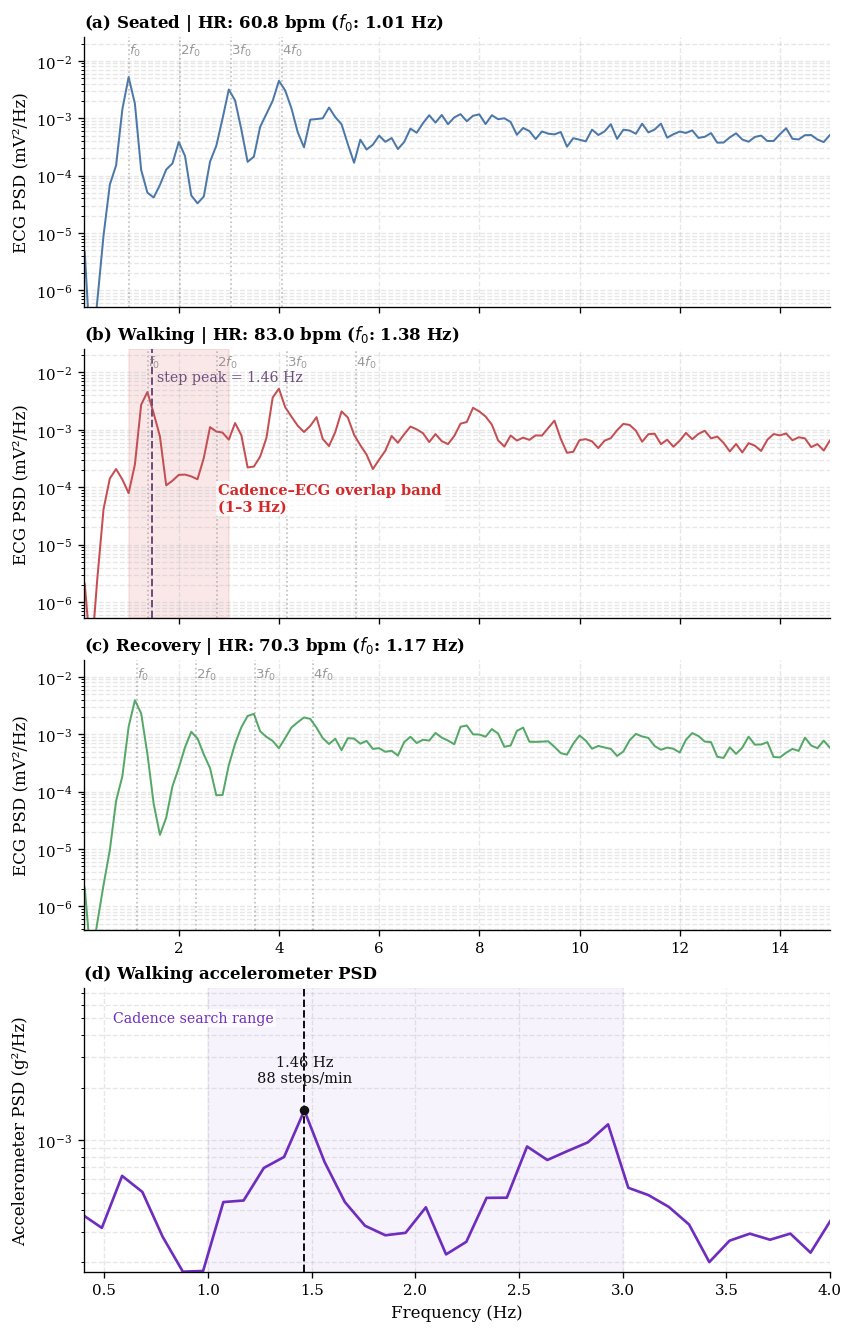

In [28]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import welch
from matplotlib.transforms import blended_transform_factory

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'legend.fontsize': 9,
})

segments = ["seated", "walking", "recovery"]
colors = {"seated": "#4C78A8", "walking": "#C44E52", "recovery": "#55A868"}
seg_titles = {"seated": "Seated", "walking": "Walking", "recovery": "Recovery"}

# ------------------------------------------------------------
# Walking accelerometer PSD: estimate dominant step frequency
# ------------------------------------------------------------

t0w, t1w = cfg.E3_SEG["walking"]
m_w = (t_g >= t0w) & (t_g < t1w)

f_g, p_g = welch(
    motion_g[m_w] - np.mean(motion_g[m_w]),
    fs=cfg.FS_GSEN,
    nperseg=min(256, int(np.sum(m_w))),
)

cadence_mask = (f_g >= 0.8) & (f_g <= 3.5)
step_peak_hz = (
    float(f_g[cadence_mask][np.argmax(p_g[cadence_mask])])
    if cadence_mask.any()
    else float("nan")
)
step_peak_spm = 60.0 * step_peak_hz

# ------------------------------------------------------------
# Figure layout
# ------------------------------------------------------------

fig = plt.figure(figsize=(7, 11), constrained_layout=True)
gs = fig.add_gridspec(4, 1, height_ratios=[1, 1, 1, 1.05])

ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[1, 0], sharex=ax0)
ax2 = fig.add_subplot(gs[2, 0], sharex=ax0)
ax_g = fig.add_subplot(gs[3, 0])

ecg_axes = [ax0, ax1, ax2]

# ------------------------------------------------------------
# ECG PSD panels
# ------------------------------------------------------------

for i, (ax, seg_name) in enumerate(zip(ecg_axes, segments)):
    t0, t1 = cfg.E3_SEG[seg_name]
    i0, i1 = int(t0 * cfg.FS), int(t1 * cfg.FS)
    ecg_seg = r.ecg_filt[i0:i1]

    f_ecg, p_ecg = P.ecg_psd(ecg_seg, fs=cfg.FS, nperseg_sec=8)

    hr = r.extras["transient_hrv"][seg_name]["mean_hr_bpm"]
    f0 = hr / 60.0

    ax.semilogy(f_ecg, p_ecg, color=colors[seg_name], lw=1.2)

    harmonic_trans = blended_transform_factory(ax.transData, ax.transAxes)

    # Cardiac fundamental and harmonics
    for k in range(1, 5):
        fk = k * f0
        if fk < 15.0:
            ax.axvline(fk, color="tab:gray", linestyle=":", alpha=0.5, lw=1)
            h_label = rf"$f_0$" if k == 1 else rf"${k}f_0$"
            ax.text(
                fk, 0.98, h_label,
                transform=harmonic_trans,
                ha="left", va="top",
                fontsize=8,
                color="tab:gray",
                alpha=0.8
            )

    # Walking-specific cadence overlap region
    if seg_name == "walking":
        ax.axvspan(1.0, 3.0, color="tab:red", alpha=0.10, zorder=-1)

        ax.text(
            0.18, 0.50,
            "Cadence–ECG overlap band\n(1–3 Hz)",
            transform=ax.transAxes,
            ha="left", va="top",
            fontsize=8.8,
            color="tab:red",
            fontweight="bold",
            bbox=dict(facecolor="white", alpha=0.72, edgecolor="none", pad=1.2)
        )

        if np.isfinite(step_peak_hz):
            ax.axvline(step_peak_hz, color="#6F4E7C", linestyle="--", lw=1.2)

            ax.text(
                step_peak_hz + 0.10, 0.92,
                f"step peak = {step_peak_hz:.2f} Hz",
                transform=harmonic_trans,
                fontsize=8.5,
                color="#6F4E7C",
                ha="left",
                va="top"
            )

    ax.set_xlim(0.1, 15.0)

    mask = (f_ecg > 0.5) & (f_ecg < 10) & np.isfinite(p_ecg) & (p_ecg > 0)
    ymax = np.max(p_ecg[mask]) if np.any(mask) else np.max(p_ecg[np.isfinite(p_ecg)])
    ax.set_ylim(ymax / 10000, ymax * 5)

    ax.set_title(
        f"({chr(97+i)}) {seg_titles[seg_name]} | HR: {hr:.1f} bpm ($f_0$: {f0:.2f} Hz)",
        loc="left",
        fontsize=10,
        fontweight="bold"
    )

    ax.set_ylabel("ECG PSD (mV²/Hz)")
    ax.grid(True, which="both", linestyle="--", alpha=0.3)

    if i < 2:
        ax.tick_params(labelbottom=False)

# ------------------------------------------------------------
# Walking accelerometer PSD panel
# ------------------------------------------------------------

ax_g.semilogy(f_g, p_g, color="#6F2DBD", lw=1.6)

g_mask = (f_g >= 0.4) & (f_g <= 4.0) & np.isfinite(p_g) & (p_g > 0)

if np.any(g_mask):
    g_vals = p_g[g_mask]
    g_ymax = float(np.max(g_vals) * 5.0)
    g_ymin = float(max(np.min(g_vals), g_ymax / 1e4))
    ax_g.set_ylim(g_ymin, g_ymax)
else:
    g_ymax = ax_g.get_ylim()[1]

ax_g.axvspan(1.0, 3.0, color="#E8DDF8", alpha=0.35, zorder=-1)

if np.isfinite(step_peak_hz):
    peak_power = float(np.interp(step_peak_hz, f_g, p_g))

    ax_g.axvline(step_peak_hz, color="#111111", linestyle="--", lw=1.2)
    ax_g.scatter([step_peak_hz], [peak_power], color="#111111", s=22, zorder=5)

    ax_g.text(
        step_peak_hz,
        min(peak_power * 1.4, g_ymax / 1.25),
        f"{step_peak_hz:.2f} Hz\n{step_peak_spm:.0f} steps/min",
        fontsize=8.8,
        ha="center",
        va="bottom",
        color="#111111"
    )

ax_g.text(
    0.04, 0.92,
    "Cadence search range",
    transform=ax_g.transAxes,
    fontsize=8.5,
    ha="left",
    va="top",
    color="#6F2DBD",
    bbox=dict(facecolor="white", alpha=0.70, edgecolor="none", pad=1.2)
)

ax_g.set_xlim(0.4, 4.0)
ax_g.set_xlabel("Frequency (Hz)")
ax_g.set_ylabel("Accelerometer PSD (g²/Hz)")
ax_g.set_title("(d) Walking accelerometer PSD", loc="left", fontsize=10, fontweight="bold")
ax_g.grid(True, which="both", linestyle="--", alpha=0.3)

PL.save_figure(fig, "nb04_fig04_e3_ecg_psd.pdf")
plt.show()

## 6. motion-g(t) with smoothed envelope aligned to RR


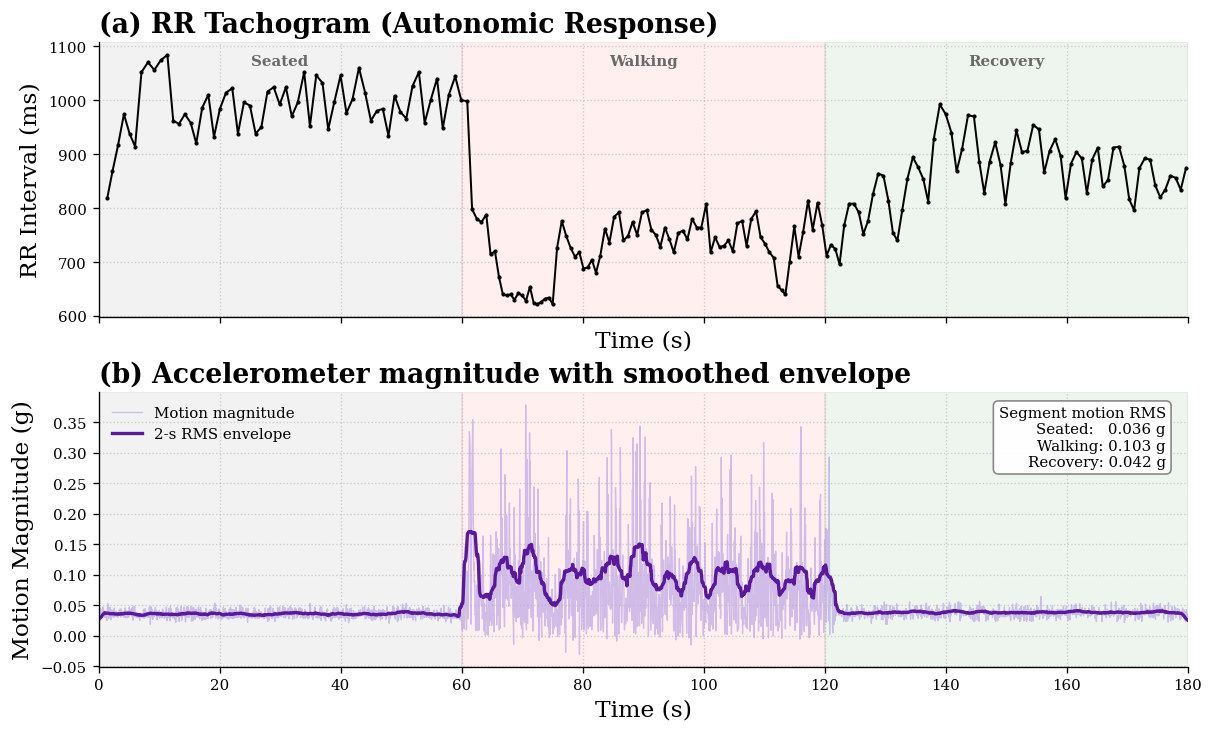

In [29]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 16,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
})

def moving_rms(x, window_samples):
    if window_samples <= 1:
        return np.asarray(x, dtype=float)
    kernel = np.ones(window_samples, dtype=float) / window_samples
    return np.sqrt(np.convolve(np.square(x), kernel, mode='same'))

env_win_s = 2.0
env_win_n = max(3, int(round(env_win_s * cfg.FS_GSEN)))
motion_env = moving_rms(motion_g, env_win_n)

motion_rms = {}
for seg_name, (t0, t1) in cfg.E3_SEG.items():
    m = (t_g >= t0) & (t_g < t1)
    motion_rms[seg_name] = float(np.sqrt(np.mean(np.square(motion_g[m])))) if np.any(m) else float("nan")

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True, constrained_layout=True)

SEG_COLORS = {"seated": "#A9A9A9", "walking": "#FF9999", "recovery": "#8FBC8F"}

ax_rr = axes[0]
PL.plot_rr_tachogram(r.rr_ms_nk, r.rr_times_nk, ax=ax_rr, color='black', lw=1.2)
ax_rr.set_title("(a) RR Tachogram (Autonomic Response)", loc='left', fontweight='bold')
ax_rr.set_ylabel("RR Interval (ms)")
ax_rr.grid(True, linestyle=':', alpha=0.6)

ax_g = axes[1]
ax_g.plot(t_g, motion_g, color="#B8A1E3", linewidth=0.8, alpha=0.65, label="Motion magnitude")
ax_g.plot(t_g, motion_env, color="#5A189A", linewidth=2.0, label=f"{env_win_s:.0f}-s RMS envelope")
ax_g.set_title("(b) Accelerometer magnitude with smoothed envelope", loc='left', fontweight='bold')
ax_g.set_ylabel("Motion Magnitude (g)")
ax_g.set_xlabel("Time (s)")
ax_g.grid(True, linestyle=':', alpha=0.6)
ax_g.set_xlim(0, 180)

for name, (t0, t1) in cfg.E3_SEG.items():
    c = SEG_COLORS.get(name, "gray")
    ax_rr.axvspan(t0, t1, color=c, alpha=0.15, zorder=-1)
    ax_g.axvspan(t0, t1, color=c, alpha=0.15, zorder=-1)
    ax_rr.text((t0 + t1) / 2, ax_rr.get_ylim()[1] * 0.98, name.capitalize(),
               ha="center", va="top", fontsize=9, fontweight='bold', color='dimgray')

stats_text = (
    "Segment motion RMS\n"
    f"Seated:   {motion_rms['seated']:.3f} g\n"
    f"Walking: {motion_rms['walking']:.3f} g\n"
    f"Recovery: {motion_rms['recovery']:.3f} g"
)
ax_g.text(
    0.98, 0.95, stats_text,
    transform=ax_g.transAxes,
    fontsize=9,
    color='black',
    ha='right',
    va='top',
    bbox=dict(boxstyle='round,pad=0.35', facecolor='white', alpha=0.92, edgecolor='gray'),
)
ax_g.legend(loc="upper left", framealpha=0.95)

PL.save_figure(fig, 'nb04_fig05_e3_motion_crosscheck.pdf')
plt.show()


,Segment,Step peak (Hz),Step peak (steps/min),Mean coherence 1–3 Hz,Max coherence 1–3 Hz,Coherence at step peak,Mean coherence ±0.15 Hz around step,Interpretation
0,walking,1.465,87.891,0.062,0.196,0.043,0.045,ECG–motion spectral coupling near cadence band


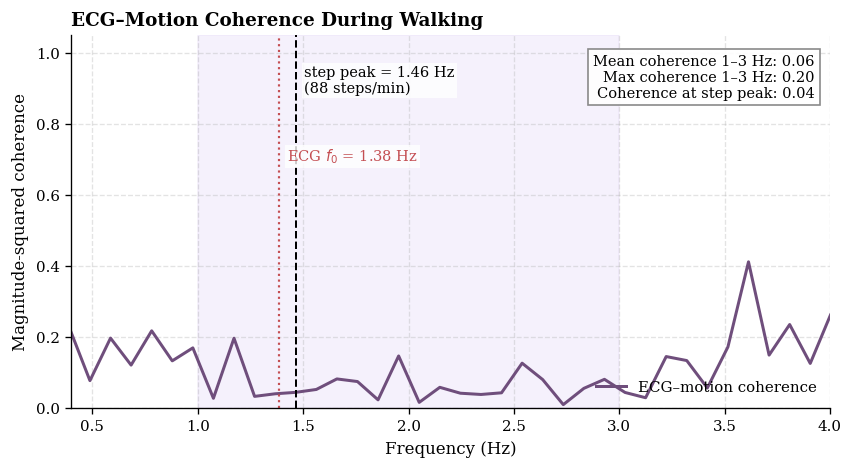

In [30]:
# ============================================================
# ECG–motion coherence during walking
# Purpose:
# Test whether walking motion and ECG share frequency components
# near the accelerometer-derived step frequency.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import coherence, resample_poly, detrend
from math import gcd

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'legend.fontsize': 9,
})

# ------------------------------------------------------------
# 1. Extract walking ECG and walking accelerometer magnitude
# ------------------------------------------------------------

t0w, t1w = cfg.E3_SEG["walking"]

# ECG segment: sampled at cfg.FS, usually 500 Hz
i0, i1 = int(t0w * cfg.FS), int(t1w * cfg.FS)
ecg_w = r.ecg_filt[i0:i1].astype(float)

# Motion segment: sampled at cfg.FS_GSEN, usually 25 Hz
m_w = (t_g >= t0w) & (t_g < t1w)
motion_w = motion_g[m_w].astype(float)

# ------------------------------------------------------------
# 2. Resample ECG to accelerometer sampling rate
# ------------------------------------------------------------
# Coherence requires both signals to have the same sampling rate.
# Because ECG is 500 Hz and accelerometer is 25 Hz, ECG is downsampled.
# resample_poly applies anti-alias filtering internally.

fs_ecg = int(cfg.FS)
fs_motion = int(cfg.FS_GSEN)

gcd_fs = gcd(fs_ecg, fs_motion)
up = fs_motion // gcd_fs
down = fs_ecg // gcd_fs

ecg_w_ds = resample_poly(ecg_w, up=up, down=down)

# Match lengths after resampling
n = min(len(ecg_w_ds), len(motion_w))
ecg_w_ds = ecg_w_ds[:n]
motion_w = motion_w[:n]

# Remove mean / linear trend before coherence
ecg_w_ds = detrend(ecg_w_ds - np.mean(ecg_w_ds))
motion_w = detrend(motion_w - np.mean(motion_w))

# ------------------------------------------------------------
# 3. Compute magnitude-squared coherence
# ------------------------------------------------------------

nperseg = min(256, n)
noverlap = nperseg // 2

f_coh, cxy = coherence(
    ecg_w_ds,
    motion_w,
    fs=fs_motion,
    nperseg=nperseg,
    noverlap=noverlap,
)

# ------------------------------------------------------------
# 4. Coherence summary metrics
# ------------------------------------------------------------

cadence_band = (f_coh >= 1.0) & (f_coh <= 3.0)

if np.isfinite(step_peak_hz):
    step_band = (f_coh >= step_peak_hz - 0.15) & (f_coh <= step_peak_hz + 0.15)
else:
    step_band = np.zeros_like(f_coh, dtype=bool)

mean_coh_1_3 = float(np.nanmean(cxy[cadence_band])) if np.any(cadence_band) else np.nan
max_coh_1_3 = float(np.nanmax(cxy[cadence_band])) if np.any(cadence_band) else np.nan
coh_at_step = float(np.interp(step_peak_hz, f_coh, cxy)) if np.isfinite(step_peak_hz) else np.nan
mean_coh_step_band = float(np.nanmean(cxy[step_band])) if np.any(step_band) else np.nan

coh_summary = pd.DataFrame([{
    "Segment": "walking",
    "Step peak (Hz)": step_peak_hz,
    "Step peak (steps/min)": step_peak_spm,
    "Mean coherence 1–3 Hz": mean_coh_1_3,
    "Max coherence 1–3 Hz": max_coh_1_3,
    "Coherence at step peak": coh_at_step,
    "Mean coherence ±0.15 Hz around step": mean_coh_step_band,
    "Interpretation": "ECG–motion spectral coupling near cadence band"
}])

display(coh_summary.round(3))

# ------------------------------------------------------------
# 5. Plot coherence spectrum
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 3.8), constrained_layout=True)

ax.plot(f_coh, cxy, color="#6F4E7C", lw=1.8, label="ECG–motion coherence")

# Cadence overlap band
ax.axvspan(1.0, 3.0, color="#E8DDF8", alpha=0.40, zorder=-1)

# Step peak reference
if np.isfinite(step_peak_hz):
    ax.axvline(step_peak_hz, color="black", linestyle="--", lw=1.2)
    ax.text(
        step_peak_hz + 0.04,
        0.92,
        f"step peak = {step_peak_hz:.2f} Hz\n({step_peak_spm:.0f} steps/min)",
        transform=ax.get_xaxis_transform(),
        ha="left",
        va="top",
        fontsize=8.8,
        color="black",
        bbox=dict(facecolor="white", alpha=0.80, edgecolor="none", pad=1.2)
    )

# Optional: mark walking ECG f0
hr_walk = r.extras["transient_hrv"]["walking"]["mean_hr_bpm"]
ecg_f0_walk = hr_walk / 60.0
ax.axvline(ecg_f0_walk, color="#C44E52", linestyle=":", lw=1.3)
ax.text(
    ecg_f0_walk + 0.04,
    0.70,
    rf"ECG $f_0$ = {ecg_f0_walk:.2f} Hz",
    transform=ax.get_xaxis_transform(),
    ha="left",
    va="top",
    fontsize=8.8,
    color="#C44E52",
    bbox=dict(facecolor="white", alpha=0.80, edgecolor="none", pad=1.2)
)

# Summary box
summary_text = (
    f"Mean coherence 1–3 Hz: {mean_coh_1_3:.2f}\n"
    f"Max coherence 1–3 Hz: {max_coh_1_3:.2f}\n"
    f"Coherence at step peak: {coh_at_step:.2f}"
)

ax.text(
    0.98, 0.95,
    summary_text,
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=8.8,
    bbox=dict(facecolor="white", alpha=0.92, edgecolor="gray", pad=3)
)

ax.set_xlim(0.4, 4.0)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Magnitude-squared coherence")
ax.set_title(
    "ECG–Motion Coherence During Walking",
    loc="left",
    fontweight="bold"
)
ax.grid(True, linestyle="--", alpha=0.35)
ax.legend(loc="lower right", framealpha=0.95)

PL.save_figure(fig, "nb04_fig05_e3_ecg_motion_coherence.pdf")
plt.show()

## 7. Table 3.1 — per-segment stats + anchor comparison

In [31]:
if 'motion_rms' not in globals():
    motion_rms = {}
    for seg_name, (t0, t1) in cfg.E3_SEG.items():
        m = (t_g >= t0) & (t_g < t1)
        motion_rms[seg_name] = float(np.sqrt(np.mean(np.square(motion_g[m])))) if np.any(m) else float("nan")

rows = []
for seg_name, d in r.extras["transient_hrv"].items():
    rows.append({
        "Segment": seg_name,
        "Range (s)": f"{cfg.E3_SEG[seg_name][0]:.0f}-{cfg.E3_SEG[seg_name][1]:.0f}",
        "n_beats":   d["n_beats"],
        "Mean HR (bpm)": d["mean_hr_bpm"],
        "Min HR (bpm)":  d["min_hr_bpm"],
        "Max HR (bpm)":  d["max_hr_bpm"],
        "RMSSD (ms)":    d["rmssd_ms"],
        "HR slope (bpm/s)": d["hr_slope_bpm_per_s"],
        "Motion RMS (g)": motion_rms.get(seg_name, float("nan")),
        "Note":      "**UNRELIABLE (motion)**" if seg_name == "walking" else "",
    })
rows.append({
    "Segment": "E1B anchor",
    "Range (s)": "300 (5 min)",
    "n_beats": int(r_anc.peaks_nk.size),
    "Mean HR (bpm)": r_anc.td_hrv["mean_hr_bpm"],
    "Min HR (bpm)":  r_anc.td_hrv["min_hr_bpm"],
    "Max HR (bpm)":  r_anc.td_hrv["max_hr_bpm"],
    "RMSSD (ms)":    r_anc.td_hrv["rmssd_ms"],
    "HR slope (bpm/s)": float("nan"),
    "Motion RMS (g)": float("nan"),
    "Note": "seated reference",
})
df_t31 = pd.DataFrame(rows)
df_t31["Recovery τ (s)"] = ""
df_t31.loc[df_t31["Segment"]=="recovery", "Recovery τ (s)"] = f"{tau:.1f}" if fit_ok else ""
df_t31.to_csv(TBL_DIR / "table_3_1_walking.csv", index=False)
df_t31.style.set_caption("Table 3.1 — E3 segment HRV vs E1B sitting anchor")


,Segment,Range (s),n_beats,Mean HR (bpm),Min HR (bpm),Max HR (bpm),RMSSD (ms),HR slope (bpm/s),Motion RMS (g),Note,Recovery τ (s)
0,seated,0-60,60,60.844730,55.350554,73.349633,54.396535,-0.054605,0.036089,,
1,walking,60-120,82,83.047285,60.120240,96.463023,41.060630,-0.119521,0.103279,**UNRELIABLE (motion)**,
2,recovery,120-180,70,70.284360,60.483871,86.206897,46.872630,-0.134047,0.041697,,6.8
3,E1B anchor,300 (5 min),279,56.097250,49.180328,71.090047,61.126947,nan,nan,seated reference,


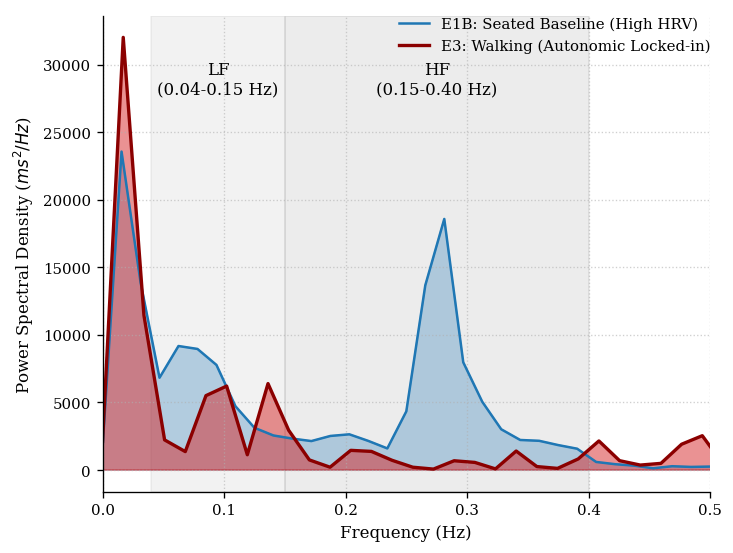

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 統一 IEEE 標準字體設定
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
})

fig, ax = plt.subplots(figsize=(6, 4.5), constrained_layout=True)

# 2. E1B (Sitting) — Welch PSD of interpolated RR (same path as fd_hrv scalars)
freqs_anc, psd_anc = P.rr_psd(r_anc.rr_ms_scipy, r_anc.rr_times_scipy)

# 3. E3 (Walking) — walking-segment RR only (transient_hrv has time-domain stats, not PSD)
t0w, t1w = cfg.E3_SEG["walking"]
mw = (r.rr_times_nk >= t0w) & (r.rr_times_nk < t1w)
freqs_walk, psd_walk = P.rr_psd(r.rr_ms_nk[mw], r.rr_times_nk[mw])

# 4. 繪製對比圖
# E1B Baseline (使用半透明藍色區域，展現充沛的自律神經能量)
ax.fill_between(freqs_anc, psd_anc, color='tab:blue', alpha=0.3)
ax.plot(freqs_anc, psd_anc, color='tab:blue', lw=1.5, label='E1B: Seated Baseline (High HRV)')

# E3 Walking (使用強烈的紅色線條，展現能量被壓平的狀態)
ax.fill_between(freqs_walk, psd_walk, color='tab:red', alpha=0.5)
ax.plot(freqs_walk, psd_walk, color='darkred', lw=2.0, label='E3: Walking (Autonomic Locked-in)')

# 5. 標記頻段區域 (LF / HF)
ax.axvspan(0.04, 0.15, color='gray', alpha=0.1, zorder=-1)
ax.text(0.095, ax.get_ylim()[1]*0.9, 'LF\n(0.04-0.15 Hz)', ha='center', va='top', color='black', fontsize=10)

ax.axvspan(0.15, 0.40, color='gray', alpha=0.15, zorder=-1)
ax.text(0.275, ax.get_ylim()[1]*0.9, 'HF\n(0.15-0.40 Hz)', ha='center', va='top', color='black', fontsize=10)

# 6. 排版優化
ax.set_xlim(0, 0.5) # RR PSD 通常只看到 0.5 Hz
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Power Spectral Density ($ms^2/Hz$)')
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(
    loc='upper right', bbox_to_anchor=(1.01, 1.01),
    borderaxespad=0, framealpha=0.9,
)

PL.save_figure(fig, 'nb04_fig06_e3_rr_psd_contrast.pdf')
plt.show()